# Step 1: Import Libraries & Data Loading 

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\nidhi\OneDrive\Desktop\Customer-Churn-Project\data\churn.csv")

print(df.shape)
df.head()

(7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64

# Step 2: Data Cleaning 

In [6]:
# copy to avoid warnings 
df = df.copy()

In [7]:
# total charges fix 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing in TotalCharges:", df['TotalCharges'].isnull().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

Missing in TotalCharges: 11


In [8]:
# Churn fix 
print(df['Churn'].unique())

['No' 'Yes']


In [9]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
print("Nulls in Churn:", df['Churn'].isnull().sum())
print("Shape:", df.shape)

Nulls in Churn: 0
Shape: (7043, 23)


In [11]:
# dtype fix
df['Churn'] = df['Churn'].astype(int)

In [12]:
# Drop customerID 
df = df.drop(columns=['customerID'], errors='ignore')

In [13]:
df.shape
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64

### Data Cleaning

- Converted TotalCharges to numeric and handled missing values using median
- Encoded target variable Churn into binary (0/1)
- Removed unnecessary columns like customerID
- Verified dataset for missing values and consistency

# Step 3: Bascic EDA 

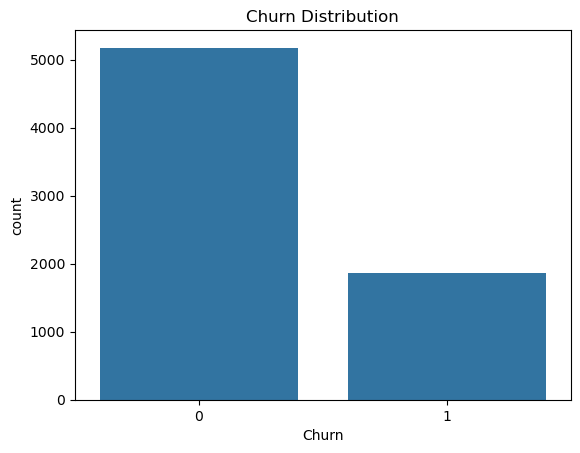

In [14]:
#  1. Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [15]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

### Insight: 
 Around 26.5% of customers have churned, indicating a moderate class imbalance in the dataset. This suggests that evaluation metrics beyond accuracy, such as precision, recall, and ROC-AUC, will be important for model performance.

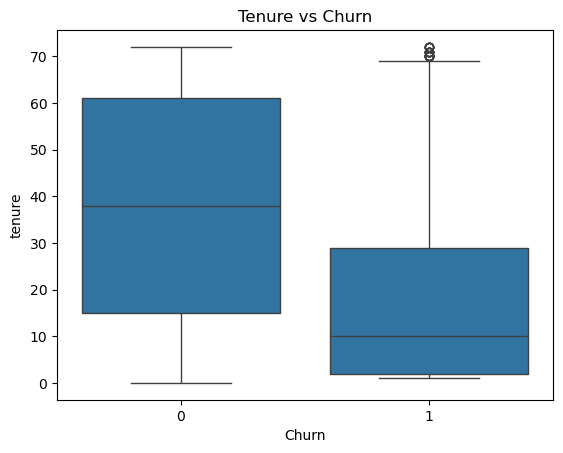

In [16]:
# 2. Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### Insight: 
Low tenure customers are more likely to churn

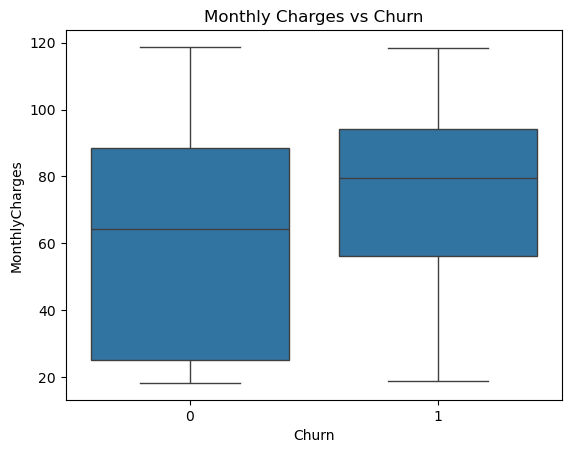

In [17]:
# 3. MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight:
Customers with higher monthly charges show higher churn tendency

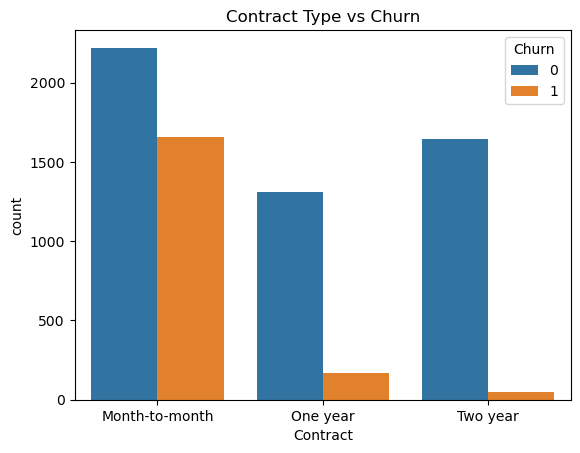

In [18]:
# 4. Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

### Insight:
Month-to-month contracts have highest churn

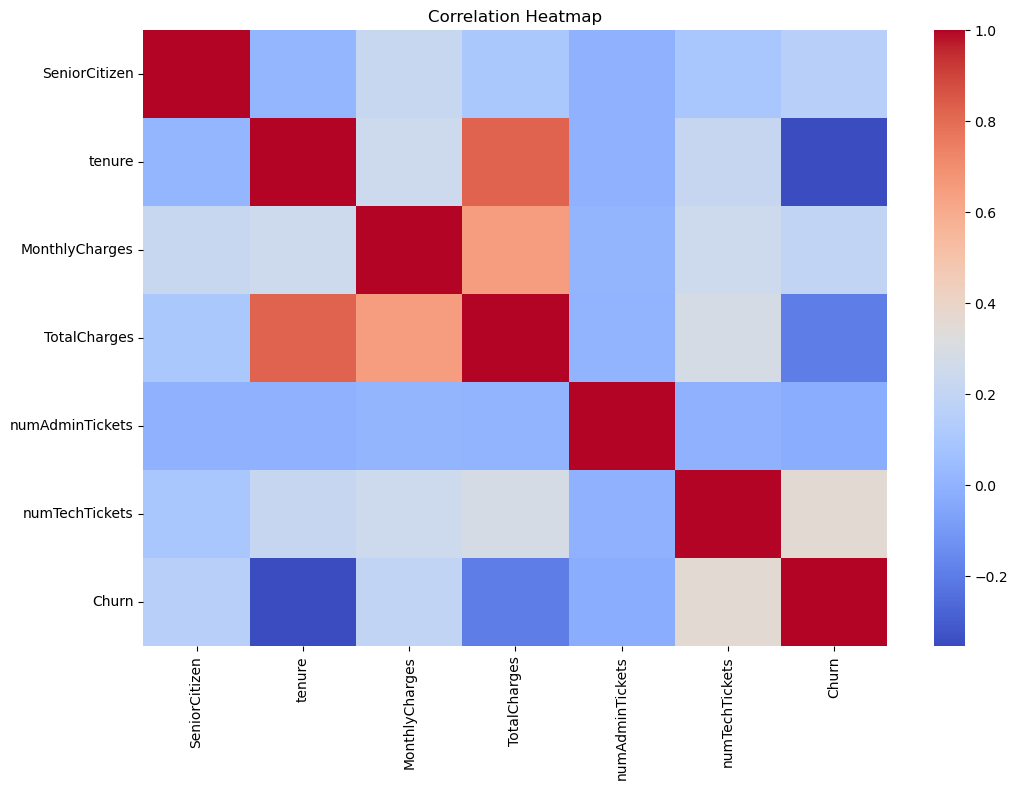

In [19]:
# 5. PaymentMethod vs Churn
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Insight: 
The correlation heatmap shows that features like tenure, MonthlyCharges, and TotalCharges have noticeable relationships with churn, indicating their importance in predicting customer behavior.

# Step 4: Advanced EDA 

In [20]:
# helper function 
def churn_rate(col):
    return df.groupby(col)['Churn'].mean()

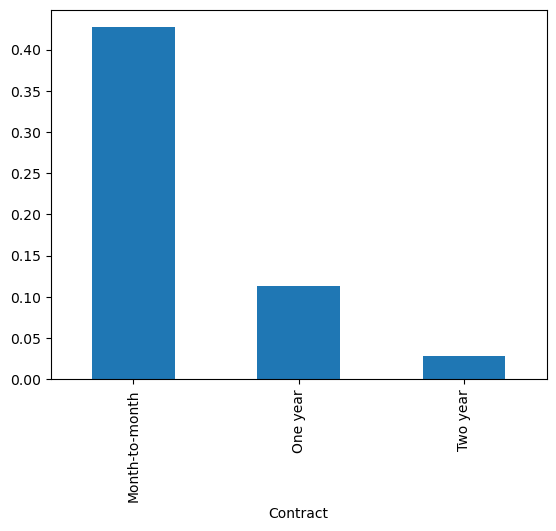

In [21]:
# 1. Contract churn rate
churn_rate('Contract').plot(kind='bar')
plt.show()

### Insight: 
Customers with month-to-month contracts have the highest churn rate, while those with one-year and two-year contracts show significantly lower churn.
This indicates that long-term commitments improve customer retention, whereas flexible contracts increase the likelihood of customers leaving.

C:\Users\nidhi\AppData\Local\Temp\ipykernel_24900\1304021214.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(col)['Churn'].mean()


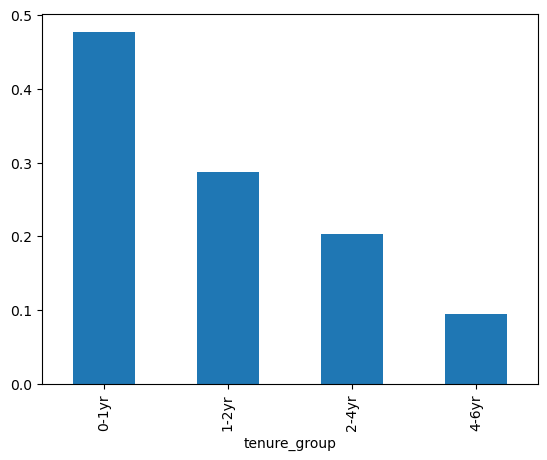

In [22]:
# 2. Tenure grouping
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

churn_rate('tenure_group').plot(kind='bar')
plt.show()

### Insight: 
Customers with lower tenure (especially within the first year) exhibit the highest churn rates. As tenure increases, churn rate decreases steadily.
This suggests that customer retention is most critical during the early stages of the customer lifecycle.

C:\Users\nidhi\AppData\Local\Temp\ipykernel_24900\1304021214.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(col)['Churn'].mean()


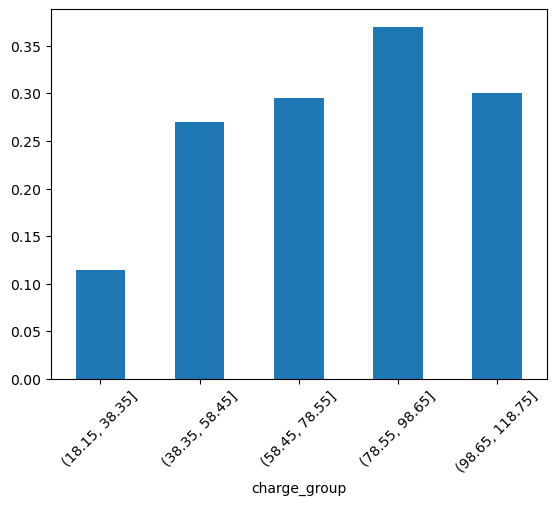

In [23]:
# 3. Charges grouping
df['charge_group'] = pd.cut(df['MonthlyCharges'], bins=5)

churn_rate('charge_group').plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

#### Insight: 
Customers with higher monthly charges tend to churn more compared to those with lower charges.
This indicates that pricing plays a significant role in customer decisions, and high-cost plans may lead to dissatisfaction or switching behavior.

# Step 5 : Feature & Target Split 

In [24]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Step 6: Categorical & Numerical Split

In [25]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'numAdminTickets', 'numTechTickets', 'tenure_group', 'charge_group'],
      dtype='object')


# Step 7: Encoding 

## Label Encoding (binary columns)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    if X[col].nunique() == 2:
        X[col] = le.fit_transform(X[col])

## One-Hot Encoding (multi-category)

In [27]:
X = pd.get_dummies(X, columns=[col for col in cat_cols if X[col].nunique() > 2], drop_first=True)

In [28]:
# Drop columns 
X = X.drop(columns=['tenure_group', 'charge_group'], errors='ignore')

In [29]:
X.shape

(7043, 32)

# Step 8: Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 32)
Test shape: (1409, 32)


# Step 9: Numerical Columns Update 

In [31]:
num_cols = X_train.select_dtypes(exclude='object').columns

print(num_cols)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'numAdminTickets', 'numTechTickets', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


# Step 10: Feature Scaling 

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Step 11: Model 1- Logistic Regression 

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8594748048261178
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1036
           1       0.74      0.73      0.73       373

    accuracy                           0.86      1409
   macro avg       0.82      0.82      0.82      1409
weighted avg       0.86      0.86      0.86      1409



# Step 12: Model 2 — Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8545067423704755
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1036
           1       0.75      0.68      0.71       373

    accuracy                           0.85      1409
   macro avg       0.82      0.80      0.81      1409
weighted avg       0.85      0.85      0.85      1409



# Step 13: Compare Models 

In [35]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8594748048261178
Random Forest: 0.8545067423704755


### Model Building and Evaluation

The dataset was split into training and testing sets using an 80:20 ratio. Feature scaling was applied to numerical features to improve model performance.
Two models were trained:
- Logistic Regression for baseline performance
- Random Forest Classifier for capturing complex patterns
The models were evaluated using accuracy and classification metrics, and their performances were compared.

# Step 14: Confusion Matrix

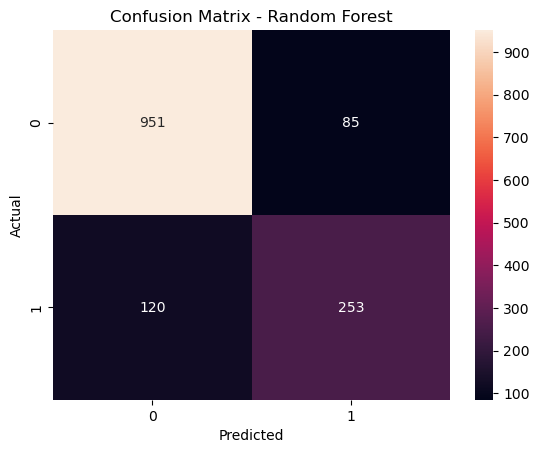

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows the model’s performance in terms of correct and incorrect predictions.
- True Positives: Correctly predicted churn customers
- True Negatives: Correctly predicted non-churn customers
- False Positives & False Negatives indicate prediction errors
This helps in understanding model reliability beyond accuracy.

# Step 15: Feature Importance

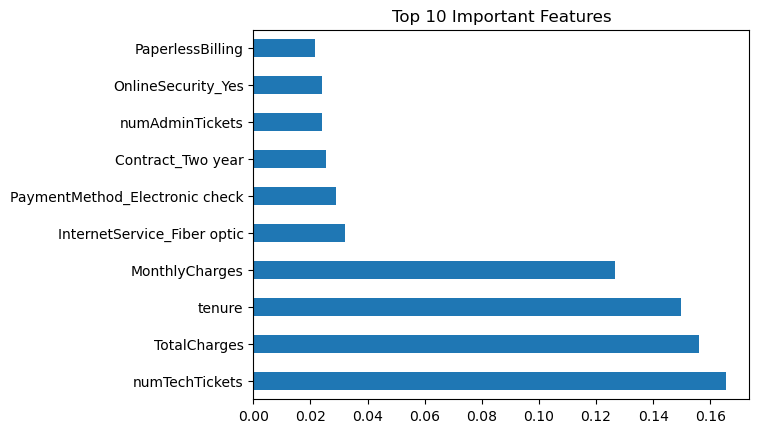

In [37]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

# Step 16: Accuracy Improve 

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred_rf))

Improved Accuracy: 0.8616039744499645


# Model save 

In [39]:
import os

folders = ['data', 'notebooks', 'src', 'models', 'outputs']

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
